In [2]:
import pickle
from matplotlib import pyplot as plt
from matplotlib.axes import Axes
import numpy as np
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
from collections import Counter

from hubo_qaoa.utils.graph_to_hubo_hamiltonian import graph_to_hubo_hamiltonian
from hubo_qaoa.utils.gfa_utils import gfa_file_to_graph
from qiskit_qaoa.utils.string_utils import evaluate_sparse_pauli_samples

In [3]:
filename, maxdb, maxdg, shots, normalise = 'test_N7_W3', 0.5, 4.25, 4000, False
with open(f'/lustre/scratch127/qpg/jc59/new_hubo_formulation/nonvariational/nonvariational.{filename}.db{maxdb}.dg{maxdg}.shots{shots}.pkl', 'rb') as f:
    res = pickle.load(f)
energies = res['energies']
delta_bs = res['delta_bs']
delta_gs = res['delta_gs']
ps = res['ps']
energies = np.array(energies)
if normalise:
    energies /= energies.max()
    # energies /= energies[0,0]
energies[1, 3, 0], ps[1], delta_bs[3], delta_gs[0]



(np.float64(0.71975), 6, np.float64(0.4), np.float64(3.75))

In [4]:
def plot_3d(axs, filename, maxdb, maxdg, shots, normalise=True):
    with open(f'/lustre/scratch127/qpg/jc59/new_hubo_formulation/nonvariational/nonvariational.{filename}.db{maxdb}.dg{maxdg}.shots{shots}.pkl', 'rb') as f:
        res = pickle.load(f)
    energies = res['energies']
    delta_bs = res['delta_bs']
    delta_gs = res['delta_gs']
    ps = res['ps']
    energies = np.array(energies)
    if normalise:
        energies /= energies.max()
        # energies /= energies[0,0]
    
    plot_ps = [int(np.floor(x)) for x in np.linspace(0, len(ps)-1, len(axs))]    
    for i in range(len(axs)):
        ax = axs[i]
        im = ax.pcolormesh(delta_bs, delta_gs, energies[plot_ps[i],:,:].T, shading='nearest')
        ax.set_xlabel(r'$\Delta_\beta$')
        ax.set_ylabel(r'$\Delta_\gamma$')
        ax.set_title(ps[plot_ps[i]])
        cbar = ax.figure.colorbar(im, ax=ax)
        label = r'$\frac{H_C}{\max(H_C)}$' if normalise else '${H_C}$'
        cbar.ax.set_ylabel(label, rotation=0, va="bottom", labelpad=25)
    return axs

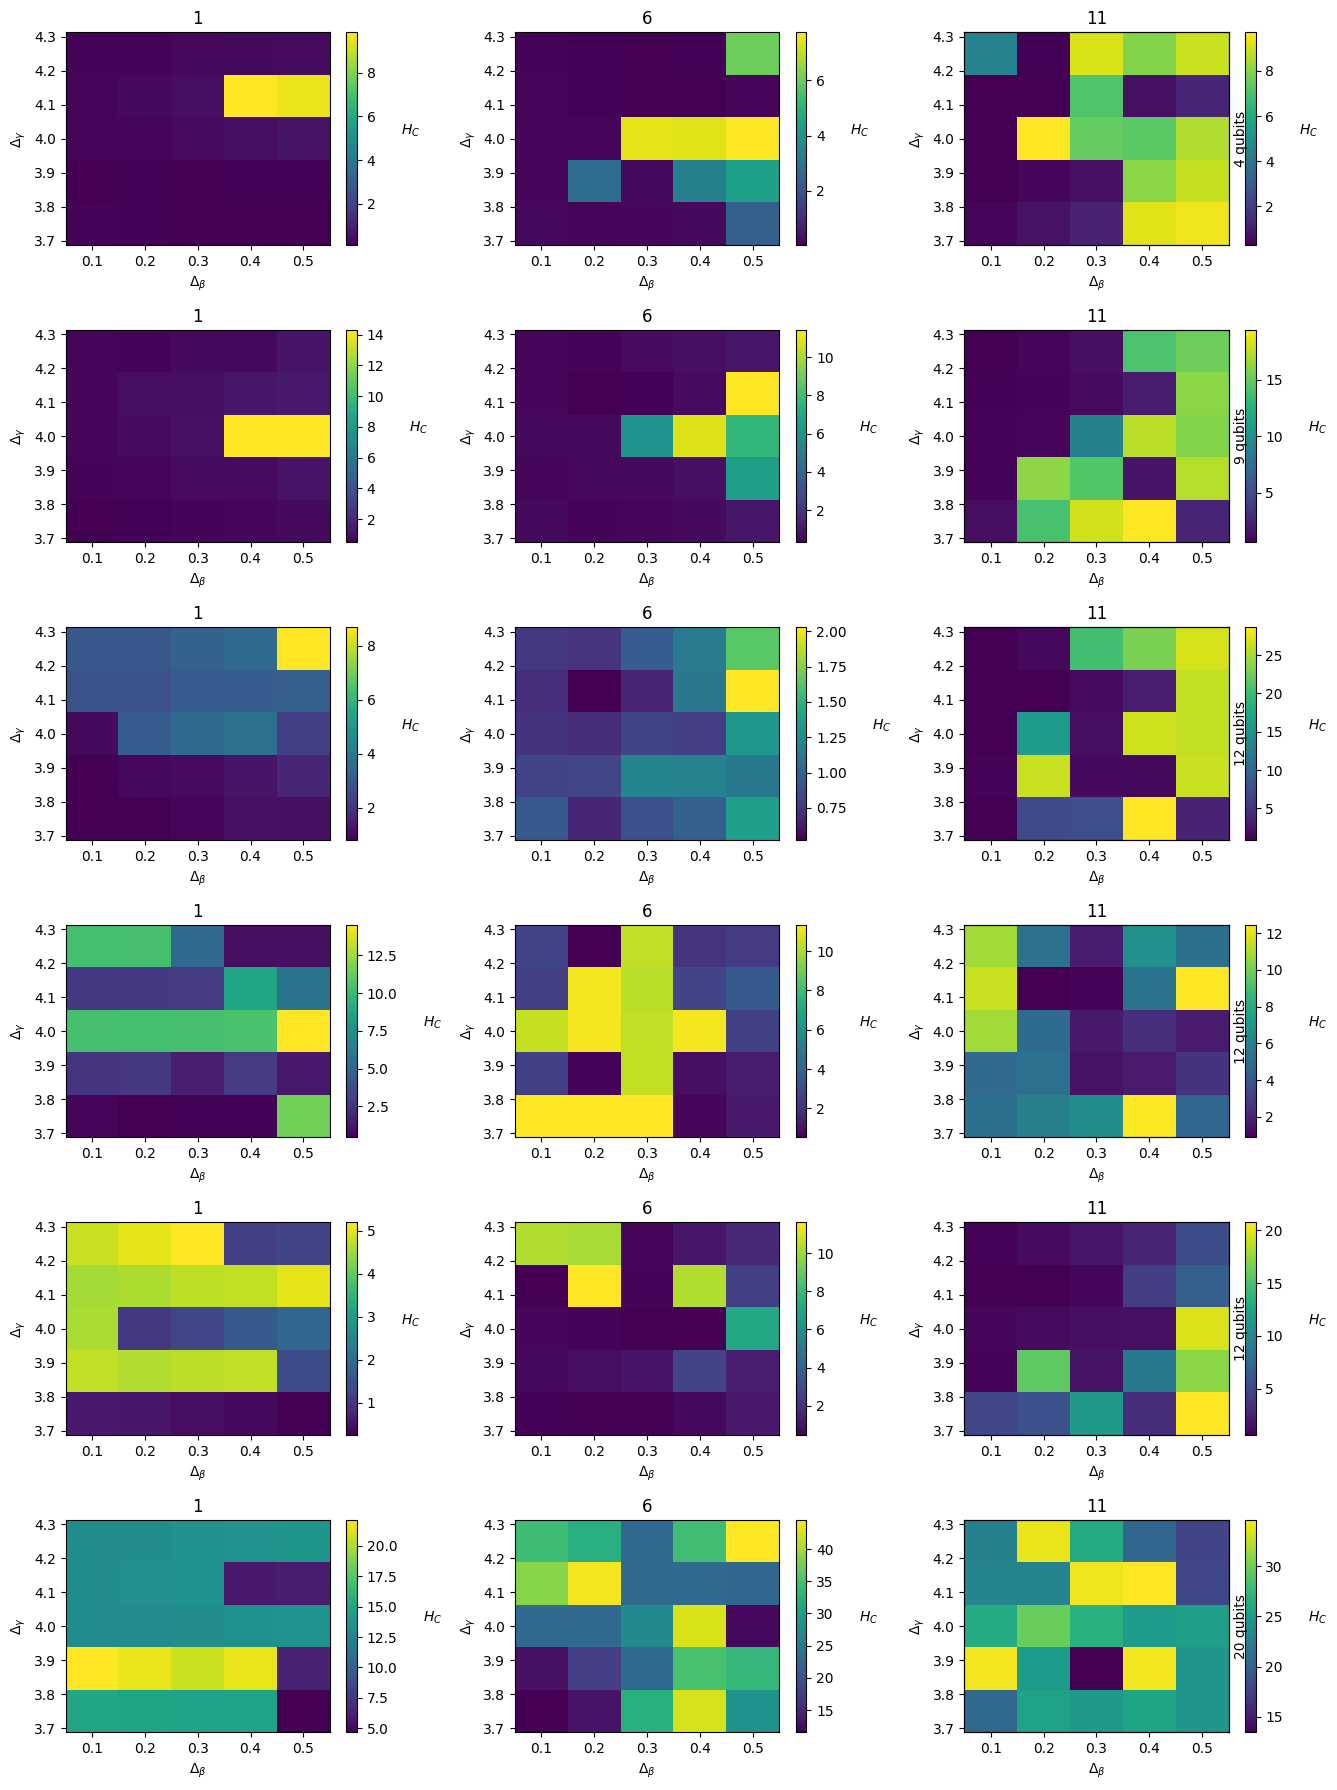

In [5]:
fig, axs = plt.subplots(6, 3)
axs0 = axs[0, :]
axs1 = axs[1, :]
axs2 = axs[2, :]
axs3 = axs[3, :]
axs4 = axs[4, :]
axs5 = axs[5, :]


axs0 = plot_3d(axs0, 'test_N2_W2', 0.5, 4.25, 4000, False)
axs1 = plot_3d(axs1, 'trivial', 0.5, 4.25, 4000, False)
axs2 = plot_3d(axs2, 'test_N3_W4', 0.5, 4.25, 4000, False)
axs3 = plot_3d(axs3, 'test_N7_W3', 0.5, 4.25, 4000, False)
axs4 = plot_3d(axs4, 'test_N8_W3', 0.5, 4.25, 4000, False)
axs5 = plot_3d(axs5, 'test_N8_W5', 0.5, 4.25, 4000, False)


qubits = [4, 9, 12, 12, 12, 20]
for idx, ax in enumerate(axs[:, -1]):
    twin = ax.twinx()
    twin.set_yticks([])
    twin.set_ylabel(f'{qubits[idx]} qubits')

fig.set_figheight(18)
fig.set_figwidth(13.5)
plt.tight_layout()

In [6]:
def plot_dist(
    axs: list[Axes], 
    filename, copy_numbers, maxdb, maxdg, shots,
    p = 6, db = 0.1, dg = 4.0,
    normalise=True
) -> list[Axes]:
    filepath = f'/nfs/users/nfs_j/jc59/quantumwork/pangenome/data/{filename}.gfa'
    graph, n, V, T = gfa_file_to_graph(filepath, copy_numbers)
    hamiltonian = graph_to_hubo_hamiltonian(graph, n, T, lamda=10, constraint_terms=1.0)
    with open(f'/lustre/scratch127/qpg/jc59/new_hubo_formulation/nonvariational/nonvariational.{filename}.db{maxdb}.dg{maxdg}.shots{shots}.pkl', 'rb') as f:
        res = pickle.load(f)
        
    
    samples_dict: dict[tuple, str] = res['samples_dict']
    energies = res['energies']
    iters = ['0', '5', '9']
    energies = np.array(energies)
    if normalise:
        energies /= energies.max()
        # energies /= energies[0,0]
    
    
    keys = samples_dict.keys()
    true_key = None
    for key in keys:
        if key[0] == p and np.abs(key[1] - db)**2 < 0.005 and np.abs(key[2] - dg)**2 < 0.005:
            true_key = key
            break
    if true_key is None:
        raise Exception('Could not find key')
    print(filename, true_key)

    cutoff=25
    for i in range(len(axs)):
        ax = axs[i]
        counter = Counter(samples_dict[true_key][i])
        evals = evaluate_sparse_pauli_samples(list(counter.keys()), hamiltonian)
        energies = [count * [evals[idx]] for idx, count in enumerate(counter.values()) if evals[idx] < cutoff]
        sample_vals = np.array([x for xs in energies for x in xs])

        ax.hist(sample_vals, bins=range(cutoff+1), weights=[1/shots]*len(sample_vals), rwidth=1, log=True)
        ax.set_xlim(0,cutoff)
        ax.set_ylim(10**-3, 10**0)

        ax.xaxis.set_major_locator(MultipleLocator(10))
        ax.xaxis.set_minor_locator(AutoMinorLocator(10))
        ax.tick_params(axis='x', which='major', length=6)
        ax.tick_params(axis='x', which='minor', length=2)
        ax.text(.95, .99, f'Iter = {iters[i]}', ha='right', va='top', transform=ax.transAxes)

    return axs

Keeping constraints at times: [0]
test_N2_W2 (6, np.float64(0.1), np.float64(4.0))
Keeping constraints at times: [0 1]
trivial (6, np.float64(0.1), np.float64(4.0))
Keeping constraints at times: [0 1 2]
test_N3_W4 (6, np.float64(0.1), np.float64(4.0))
Keeping constraints at times: [0 1]
test_N7_W3 (6, np.float64(0.4), np.float64(3.75))
Keeping constraints at times: [1 0]
test_N8_W3 (6, np.float64(0.1), np.float64(4.0))
Keeping constraints at times: [3 2 0 1]
test_N8_W5 (6, np.float64(0.1), np.float64(4.0))


/tmp/ipykernel_2036190/3048515534.py:42: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax.set_xlim(0,cutoff)


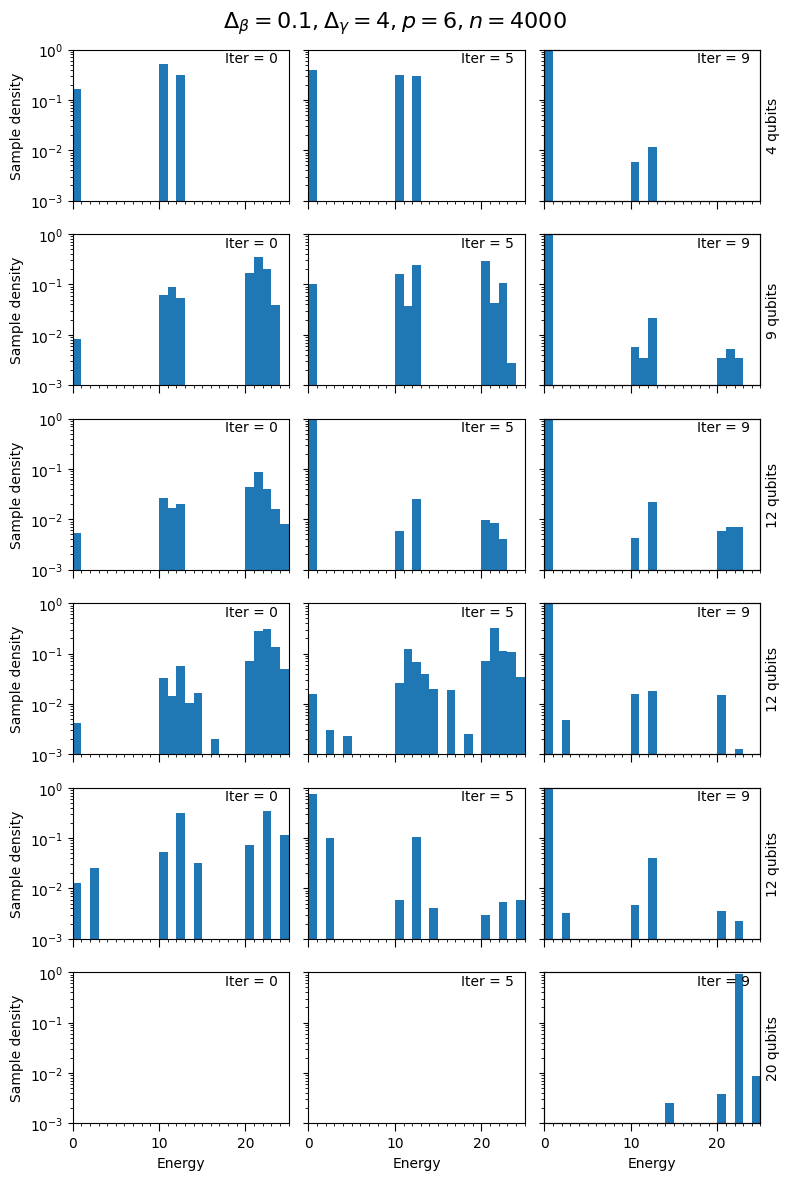

In [8]:
fig, axs = plt.subplots(6, 3, sharey='row', sharex='col')
p = 6
db = 0.1
dg = 4
axs0 = axs[0, :]
axs1 = axs[1, :]
axs2 = axs[2, :]
axs3 = axs[3, :]
axs4 = axs[4, :]
axs5 = axs[5, :]


axs0 = plot_dist(axs0, 'test_N2_W2', [1,1], 0.5, 4.25, 4000, p=p, db=db, dg=dg, normalise=False)
axs1 = plot_dist(axs1, 'trivial', [1,1,1], 0.5, 4.25, 4000, p=p, db=db, dg=dg, normalise=False)
axs2 = plot_dist(axs2, 'test_N3_W4', [2,1,1], 0.5, 4.25, 4000, p=p, db=db, dg=dg,normalise=False)

# Different params!!
axs3 = plot_dist(axs3, 'test_N7_W3', [1,1,0,0,0,0,1], 0.5, 4.25, 4000, p=p, db=0.4, dg=3.75, normalise=False)

axs4 = plot_dist(axs4, 'test_N8_W3', [1,1,0,0,0,0,0,1], 0.5, 4.25, 4000, p=p, db=db, dg=dg,normalise=False)
axs5 = plot_dist(axs5, 'test_N8_W5', [1,1,1,1,0,0,0,1], 0.5, 4.25, 4000, p=p, db=db, dg=dg,normalise=False)


for ax in axs[:, 0]:
    ax.set_ylabel(r'Sample density')
    
qubits = [4, 9, 12, 12, 12, 20]
for idx, ax in enumerate(axs[:, -1]):
    twin = ax.twinx()
    twin.set_yticks([])
    twin.set_ylabel(f'{qubits[idx]} qubits')
    
for ax in axs[-1, :]:  
    ax.set_xlabel(r'Energy')  
    
fig.suptitle(f'$\\Delta_\\beta = {db}, \\Delta_\\gamma = {dg}, p = {p}, n = 4000$', fontsize=16)
fig.set_figheight(12)
fig.set_figwidth(8)
plt.tight_layout()
# fig.set_tight_layout('tight')
